# Predicción de deserción estudiantil con Machine Learning

Este notebook construye, paso a paso, un modelo que predice qué estudiantes están en riesgo de desertar, usando datos académicos y socioeconómicos reales de una institución de educación superior.

No es solo un ejercicio de clasificación. El notebook está pensado para sostener cada decisión metodológica con evidencia: por qué se elige una métrica y no otra, por qué se maneja el desbalance de clases de cierta forma, con qué variables es honesto llamarle "alerta temprana" al sistema, y por qué el checklist final puede afirmar, con aserciones que corren de verdad, que no hay fuga de datos entre entrenamiento y prueba.

Proyecto de ATLAS, el laboratorio de proyectos de FuzzyFrog.AI.

Artículo completo, con cada decisión explicada y su Explorador de alternativas: https://fuzzyfrog.ai/es/ai-lab/proyectos/educacion/modelado-retencion-estudiantil/

**Este notebook se corrió y probó de principio a fin el 25 de septiembre de 2026.** Si algo falla o encuentras un error, es probable que una librería, una API o el propio entorno de Colab haya cambiado desde entonces. Escríbenos y lo corregimos.

## Qué vas a aprender

- A construir un pipeline de clasificación sin fuga de datos: el escalado, el balanceo de clases y la selección de umbral se ajustan solo con información de entrenamiento, nunca con la prueba.
- A distinguir una variable que predice de una que solo describe el desenlace ya ocurrido, y a decidir con evidencia qué tan temprano puede alertar de verdad un modelo.
- A elegir la métrica correcta cuando las clases están desbalanceadas, en vez de confiar en el Accuracy.
- A interpretar un modelo de caja negra con SHAP, a nivel global e individual.

## 0. Configuración y reproducibilidad

- Todas las decisiones numéricas del experimento viven en esta celda: la semilla global y el esquema de validación cruzada que reutiliza el resto del notebook.
- La semilla hace que el split, el benchmarking y la afinación den los mismos números en cada corrida.
- Se imprimen las versiones de cada librería, porque un resultado sin su entorno no se puede reproducir.

In [ ]:
!pip install -q ucimlrepo shap imbalanced-learn xgboost --upgrade

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import pandas as pd
import numpy as np
import sklearn
import xgboost
import shap
import imblearn
from sklearn.model_selection import StratifiedKFold

SEED = 42
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print(f"pandas            {pd.__version__}")
print(f"numpy             {np.__version__}")
print(f"scikit-learn      {sklearn.__version__}")
print(f"xgboost           {xgboost.__version__}")
print(f"shap              {shap.__version__}")
print(f"imbalanced-learn  {imblearn.__version__}")


pandas            2.2.3
numpy             2.1.3
scikit-learn      1.6.1
xgboost           3.4.1
shap              0.52.0
imbalanced-learn  0.14.2


## Pipeline del proyecto

Siete etapas, cada una construida solo con lo que la etapa anterior le permite ver: qué variables entran, el escalado, el balanceo y el umbral se ajustan con entrenamiento o validación, nunca con la prueba.

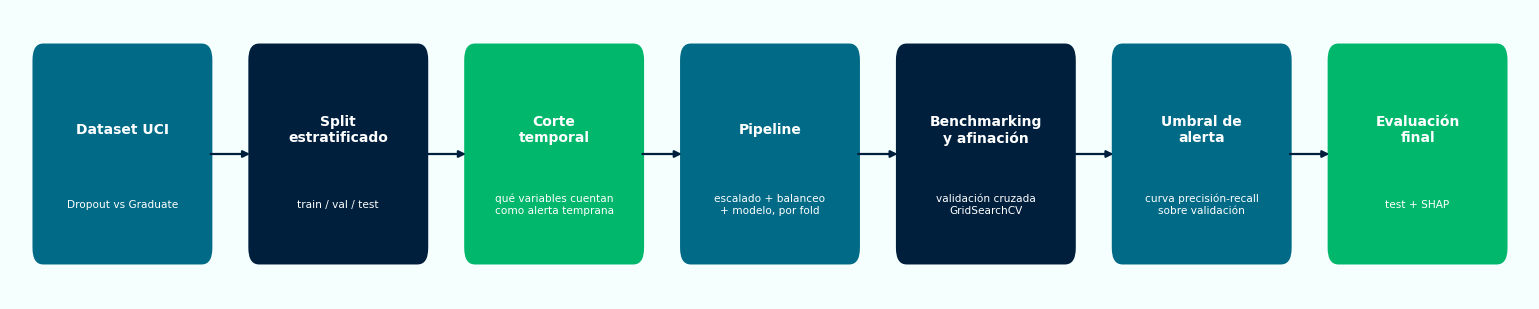

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

FF_VERDE = "#00b76c"
FF_TEAL  = "#006a87"
FF_NAVY  = "#001f3d"
FF_BG    = "#f4fffe"

pasos_pipeline = [
    ("Dataset UCI",              "Dropout vs Graduate",                       FF_TEAL),
    ("Split\nestratificado",     "train / val / test",                        FF_NAVY),
    ("Corte\ntemporal",          "qué variables cuentan\ncomo alerta temprana", FF_VERDE),
    ("Pipeline",                 "escalado + balanceo\n+ modelo, por fold",   FF_TEAL),
    ("Benchmarking\ny afinación", "validación cruzada\nGridSearchCV",         FF_NAVY),
    ("Umbral de\nalerta",        "curva precisión-recall\nsobre validación",  FF_TEAL),
    ("Evaluación\nfinal",        "test + SHAP",                                FF_VERDE),
]

ancho, alto, espacio = 1.9, 1.5, 0.5
fig, ax = plt.subplots(figsize=(15.5, 3.2))
fig.patch.set_facecolor(FF_BG)
ax.set_facecolor(FF_BG)

x = 0.0
for titulo, subtitulo, color in pasos_pipeline:
    ax.add_patch(FancyBboxPatch((x, 0), ancho, alto,
                                 boxstyle="round,pad=0.05,rounding_size=0.12",
                                 facecolor=color, edgecolor="none"))
    ax.text(x + ancho / 2, alto * 0.62, titulo, ha="center", va="center",
            color="white", fontsize=10, fontweight="bold")
    ax.text(x + ancho / 2, alto * 0.26, subtitulo, ha="center", va="center",
            color="white", fontsize=7.6)
    if x > 0:
        ax.annotate("", xy=(x, alto / 2), xytext=(x - espacio, alto / 2),
                    arrowprops=dict(arrowstyle="-|>", color=FF_NAVY, lw=1.6))
    x += ancho + espacio

ax.set_xlim(-0.3, x - espacio + 0.3)
ax.set_ylim(-0.3, alto + 0.3)
ax.axis("off")
plt.tight_layout()
plt.show()


## 1. Carga de datos

- Dataset real: **Predict Students' Dropout and Academic Success**, UCI Machine Learning Repository (Realinho et al., 2021), id 697.
- 4424 estudiantes de una institución de educación superior portuguesa, con variables académicas, demográficas y socioeconómicas registradas al momento de la inscripción y al final del 1er y 2do semestre.
- La columna objetivo original tiene tres clases: `Dropout`, `Enrolled`, `Graduate`. Este proyecto predice deserción, así que se excluye `Enrolled` (el estudiante sigue inscrito, no hay desenlace todavía) y se queda con `Dropout` vs `Graduate`.
- Se intenta la descarga en vivo con `ucimlrepo`. Si el paquete o la conexión fallan, hay una alternativa de respaldo leyendo el CSV publicado por UCI directamente.

In [ ]:
def cargar_dataset_uci():
    """Descarga el dataset real de UCI. Primero intenta ucimlrepo (más robusto,
    ya viene separado en features/target). Si falla, usa el CSV publicado
    directamente como respaldo."""
    try:
        from ucimlrepo import fetch_ucirepo
        ds = fetch_ucirepo(id=697)
        df = ds.data.features.copy()
        df["Target"] = ds.data.targets.values.ravel()
        print("Dataset cargado con ucimlrepo.")
        return df
    except Exception as e:
        print(f"ucimlrepo no disponible ({e}). Usando el CSV de respaldo de UCI.")
        url = ("https://archive.ics.uci.edu/static/public/697/"
               "predict+students+dropout+and+academic+success.zip")
        import io, zipfile, urllib.request
        with urllib.request.urlopen(url) as resp:
            contenido = resp.read()
        with zipfile.ZipFile(io.BytesIO(contenido)) as z:
            nombre_csv = [n for n in z.namelist() if n.endswith(".csv")][0]
            with z.open(nombre_csv) as f:
                df = pd.read_csv(f, sep=";")
        print("Dataset cargado desde el CSV de respaldo.")
        return df

df_crudo = cargar_dataset_uci()
print(df_crudo.shape)
df_crudo.head()


Dataset cargado con ucimlrepo.
(4424, 37)


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 2. Explicación de los datos

- Filtramos solo `Dropout` y `Graduate`: el problema queda definido como clasificación binaria.
- Variables numéricas: rendimiento académico por semestre (unidades aprobadas, calificaciones), edad, indicadores macroeconómicos del año de inscripción.
- Variables categóricas codificadas como enteros: estado civil, modo de aplicación, curso, nacionalidad, calificación de los padres, entre otras.
- Variables binarias: si el estudiante es deudor, si está al corriente con la matrícula, si tiene beca, si es desplazado, si tiene necesidades educativas especiales.
- No hay valores nulos en este dataset « es una de las razones por las que está tan citado en la literatura reciente », pero igual lo verificamos explícitamente en vez de asumirlo.

In [ ]:
df = df_crudo[df_crudo["Target"].isin(["Dropout", "Graduate"])].copy()
df["desercion"] = (df["Target"] == "Dropout").astype(int)
df.drop(columns=["Target"], inplace=True)

print(f"Filas tras filtrar Enrolled: {df.shape[0]}")
print(f"Columnas: {df.shape[1] - 1} features + 1 target")
print()
print("Valores nulos por columna (debe ser 0 en todas):")
print(df.isnull().sum().sum(), "nulos en total")
print()
print("Distribución de la clase objetivo:")
print(df["desercion"].value_counts(normalize=True).rename({0: "Graduate", 1: "Dropout"}))


Filas tras filtrar Enrolled: 3630
Columnas: 36 features + 1 target

Valores nulos por columna (debe ser 0 en todas):
0 nulos en total

Distribución de la clase objetivo:
desercion
Graduate    0.60854
Dropout     0.39146
Name: proportion, dtype: float64


## 3. Análisis exploratorio

- La clase `Dropout` es minoritaria pero no marginal, hay que revisar la proporción exacta antes de decidir cómo manejar el desbalance.
- Todas las gráficas usan la paleta de marca FuzzyFrog.AI, no los colores por defecto de matplotlib.
- La correlación de abajo se calcula sobre **todas** las variables disponibles, incluidas las del 2do semestre. La sección de Modelado retoma este punto: qué tan temprano puede alertar de verdad un modelo que se apoya en esas variables.

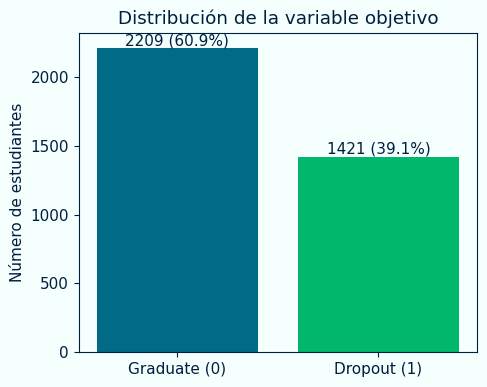

In [ ]:
FF_VERDE  = "#00b76c"
FF_TEAL   = "#006a87"
FF_CYAN   = "#32ecfd"
FF_NAVY   = "#001f3d"
FF_BG     = "#f4fffe"

plt.rcParams["figure.facecolor"] = FF_BG
plt.rcParams["axes.facecolor"]   = FF_BG
plt.rcParams["axes.edgecolor"]   = FF_NAVY
plt.rcParams["text.color"]       = FF_NAVY
plt.rcParams["axes.labelcolor"]  = FF_NAVY
plt.rcParams["xtick.color"]      = FF_NAVY
plt.rcParams["ytick.color"]      = FF_NAVY
plt.rcParams["font.size"]        = 11

fig, ax = plt.subplots(figsize=(5, 4))
conteo = df["desercion"].value_counts().sort_index()
ax.bar(["Graduate (0)", "Dropout (1)"], conteo.values, color=[FF_TEAL, FF_VERDE])
ax.set_title("Distribución de la variable objetivo")
ax.set_ylabel("Número de estudiantes")
for i, v in enumerate(conteo.values):
    ax.text(i, v + 20, f"{v} ({v/conteo.sum():.1%})", ha="center")
plt.tight_layout()
plt.show()


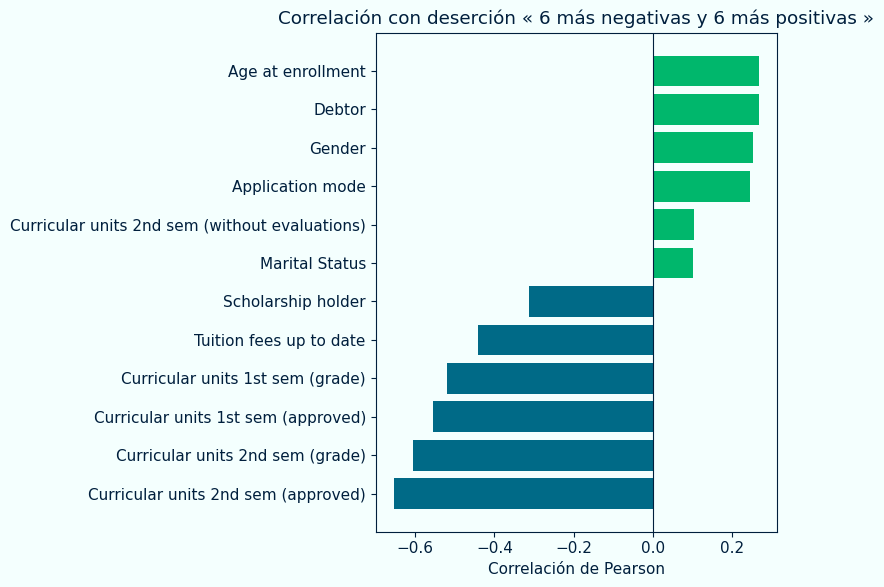

In [ ]:
corr_target = df.corr(numeric_only=True)["desercion"].drop("desercion").sort_values()
top_neg = corr_target.head(6)
top_pos = corr_target.tail(6)
top = pd.concat([top_neg, top_pos])

fig, ax = plt.subplots(figsize=(8, 6))
colores = [FF_VERDE if v > 0 else FF_TEAL for v in top.values]
ax.barh(top.index, top.values, color=colores)
ax.axvline(0, color=FF_NAVY, linewidth=0.8)
ax.set_title("Correlación con deserción « 6 más negativas y 6 más positivas »")
ax.set_xlabel("Correlación de Pearson")
plt.tight_layout()
plt.show()


## 4. Modelado

### Split estratificado

El split original de este dataset en el borrador previo no estaba estratificado por clase. Con un desbalance real de clases, un split aleatorio simple puede dejar proporciones distintas de `Dropout` en train, validación y test solo por azar, lo que hace que las métricas de validación no sean representativas de las de test.

Aquí el split es **estratificado** en las tres particiones: 70% entrenamiento, 15% validación, 15% prueba. La validación se usa más adelante para elegir el umbral de alerta. La prueba se toca una sola vez, al final.

In [ ]:
from sklearn.model_selection import train_test_split

# .astype(float) es deliberado: algunas columnas llegan de ucimlrepo con dtype
# "category". XGBoost detecta eso y activa soporte categórico automáticamente,
# lo que rompe SHAP más adelante ("Categorical split is not yet supported").
# Todas las columnas de este dataset ya son numéricas codificadas, así que
# convertir a float no pierde información, solo evita el dtype ambiguo.
X = df.drop(columns=["desercion"]).astype(float)
y = df["desercion"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

for nombre, y_split in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"{nombre:>5}: {len(y_split):4d} filas | % Dropout = {y_split.mean():.3f}")


train: 2541 filas | % Dropout = 0.392
  val:  544 filas | % Dropout = 0.392
 test:  545 filas | % Dropout = 0.391


### Decisión: ¿con qué variables predecir, hasta la admisión y el 1er semestre, o también con el 2do semestre?

**Una alerta genuinamente temprana, o una foto casi al final de la historia.**

En el análisis exploratorio de arriba, las variables con mayor correlación con la deserción son `Curricular units 2nd sem (approved)` y su familia. Tiene una explicación simple: un estudiante que deserta a la mitad del segundo semestre casi por definición aprueba pocas o ninguna unidad ese semestre, porque esas unidades se registran hasta el final del periodo, cuando la deserción ya ocurrió.

Usar esas columnas no es fuga de datos en el sentido de mezclar train y test. Es otro problema: el modelo terminaría detectando una deserción que ya pasó, no alertando con tiempo de reaccionar. Este proyecto se presenta como un sistema de alerta temprana, así que la celda siguiente decide con evidencia, comparando el mismo modelo de referencia con todas las variables contra solo las que existen al momento de la admisión y durante el 1er semestre, que es la única ventana donde una alerta temprana todavía sirve de algo.

In [ ]:
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate

COLUMNAS_2DO_SEM  = [c for c in X_train.columns if "2nd sem" in c]
COLUMNAS_TEMPRANO = [c for c in X_train.columns if c not in COLUMNAS_2DO_SEM]

def auc_recall_con_columnas(columnas):
    pipe = SkPipeline([
        ("escalado", StandardScaler()),
        ("modelo", LogisticRegression(max_iter=1000, random_state=SEED)),
    ])
    scores = cross_validate(pipe, X_train[columnas], y_train, cv=cv,
                             scoring=["roc_auc", "recall"])
    return scores["test_roc_auc"].mean(), scores["test_recall"].mean()

auc_completo, recall_completo = auc_recall_con_columnas(X_train.columns.tolist())
auc_temprano, recall_temprano = auc_recall_con_columnas(COLUMNAS_TEMPRANO)

print(f"Con todas las variables (incluye 2do semestre):        AUC={auc_completo:.4f} | Recall={recall_completo:.4f}")
print(f"Solo con variables tempranas (admisión + 1er semestre): AUC={auc_temprano:.4f} | Recall={recall_temprano:.4f}")
print(f"Costo de predecir temprano: {auc_completo - auc_temprano:+.4f} de AUC")

CORTE_ELEGIDO = "temprano"
X_train = X_train[COLUMNAS_TEMPRANO].copy()
X_val   = X_val[COLUMNAS_TEMPRANO].copy()
X_test  = X_test[COLUMNAS_TEMPRANO].copy()
X       = X[COLUMNAS_TEMPRANO].copy()

print(f"\nSe continúa con el corte '{CORTE_ELEGIDO}'. "
      f"Columnas descartadas: {len(COLUMNAS_2DO_SEM)}. Columnas usadas de aquí en adelante: {X_train.shape[1]}.")


Con todas las variables (incluye 2do semestre):        AUC=0.9463 | Recall=0.8302
Solo con variables tempranas (admisión + 1er semestre): AUC=0.9303 | Recall=0.7910
Costo de predecir temprano: +0.0159 de AUC

Se continúa con el corte 'temprano'. Columnas descartadas: 6. Columnas usadas de aquí en adelante: 30.


**Alternativa descartada:** ¿Predecir con todas las variables o solo con las que existen antes del 2do semestre? Pruébala tú y mira qué habría pasado en el [Explorador de decisiones](https://fuzzyfrog.ai/es/ai-lab/proyectos/educacion/modelado-retencion-estudiantil/#explorador-corte_temporal).

### Decisión: ¿cómo manejar el desbalance de clases?

**¿Sin balanceo, con peso de clase, o con sobremuestreo sintético (SMOTE)?**

La opción ingenua es entrenar tal cual, dejando que el modelo aprenda que la clase mayoritaria es la apuesta segura. `class_weight="balanced"` penaliza más los errores sobre la clase minoritaria, sin tocar los datos. SMOTE genera ejemplos sintéticos de la clase minoritaria antes de entrenar.

El riesgo metodológico real está en SMOTE: si se aplica **antes** del split de validación cruzada, algunos ejemplos sintéticos terminan compartiendo información con ejemplos reales que caen en el fold de validación, y las métricas de CV quedan infladas. Por eso SMOTE va **dentro** de un `Pipeline` de `imbalanced-learn`, y solo se activa en el fold de entrenamiento de cada iteración, nunca en el de validación ni en test.

Este notebook prueba las tres alternativas con validación cruzada y se queda con la que da mejor Recall sin hundir la Precisión.

In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

metricas_cv = ["roc_auc", "recall", "precision", "f1"]

estrategias_desbalance = {
    "sin_balanceo": ImbPipeline([
        ("escalado", StandardScaler()),
        ("modelo", LogisticRegression(max_iter=1000, random_state=SEED)),
    ]),
    "class_weight_balanced": ImbPipeline([
        ("escalado", StandardScaler()),
        ("modelo", LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")),
    ]),
    "smote": ImbPipeline([
        ("escalado", StandardScaler()),
        ("smote", SMOTE(random_state=SEED)),
        ("modelo", LogisticRegression(max_iter=1000, random_state=SEED)),
    ]),
}

resultados_desbalance = {}
for nombre, pipe in estrategias_desbalance.items():
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=metricas_cv)
    resultados_desbalance[nombre] = {m: scores[f"test_{m}"].mean() for m in metricas_cv}
    print(f"{nombre:>22}: " + " | ".join(f"{m}={resultados_desbalance[nombre][m]:.3f}" for m in metricas_cv))

df_desbalance = pd.DataFrame(resultados_desbalance).T
df_desbalance


          sin_balanceo: roc_auc=0.930 | recall=0.791 | precision=0.893 | f1=0.839
 class_weight_balanced: roc_auc=0.931 | recall=0.837 | precision=0.849 | f1=0.843
                 smote: roc_auc=0.931 | recall=0.843 | precision=0.842 | f1=0.843


,roc_auc,recall,precision,f1
sin_balanceo,0.930331,0.790955,0.893240,0.838980
class_weight_balanced,0.930828,0.837186,0.848940,0.842988
smote,0.930559,0.843216,0.842187,0.842607


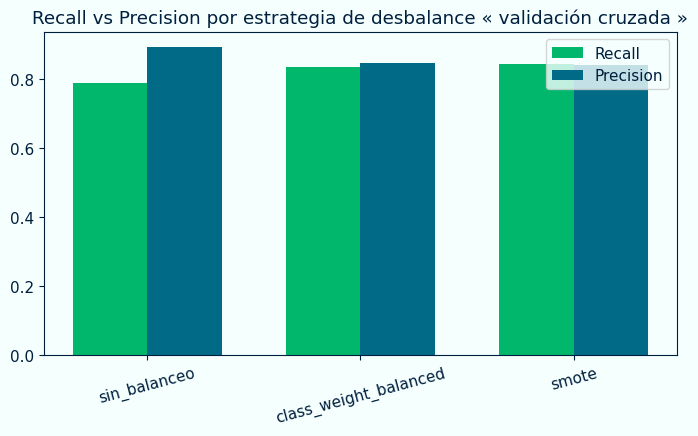

Estrategia elegida por Recall: smote


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
x_pos = np.arange(len(df_desbalance))
ancho = 0.35
ax.bar(x_pos - ancho/2, df_desbalance["recall"], ancho, label="Recall", color=FF_VERDE)
ax.bar(x_pos + ancho/2, df_desbalance["precision"], ancho, label="Precision", color=FF_TEAL)
ax.set_xticks(x_pos)
ax.set_xticklabels(df_desbalance.index, rotation=15)
ax.set_title("Recall vs Precision por estrategia de desbalance « validación cruzada »")
ax.legend()
plt.tight_layout()
plt.show()

ESTRATEGIA_ELEGIDA = df_desbalance["recall"].idxmax()
print(f"Estrategia elegida por Recall: {ESTRATEGIA_ELEGIDA}")


**Alternativa descartada:** ¿Sin balanceo, con peso de clase o con SMOTE? Pruébala tú y mira qué habría pasado en el [Explorador de decisiones](https://fuzzyfrog.ai/es/ai-lab/proyectos/educacion/modelado-retencion-estudiantil/#explorador-manejo_desbalance).

### Decisión: ¿escalar antes o dentro de cada fold de validación cruzada?

**Escalar una sola vez sobre todo train, o dentro de cada fold del `Pipeline`.**

Ajustar el `StandardScaler` una sola vez sobre todo `X_train` y después correr `cross_val_score` sobre esos datos ya escalados es un error sutil y común: cada fold de validación cruzada termina evaluándose con un escalador que también vio esos mismos datos al calcular la media y la desviación estándar globales de train. No es tan grave como filtrar el test, pero sigue siendo fuga de datos.

La celda siguiente compara ambos enfoques sobre el mismo modelo, para dejar documentada la diferencia. El pipeline correcto « escalar dentro de cada fold » es el que se usa en el resto del notebook.

In [ ]:
from sklearn.model_selection import cross_val_score

modelo_referencia = LogisticRegression(max_iter=1000, random_state=SEED)

# Enfoque con fuga: escalar una sola vez sobre todo X_train, antes de la CV
scaler_global = StandardScaler()
X_train_escalado_global = scaler_global.fit_transform(X_train)
auc_con_fuga = cross_val_score(modelo_referencia, X_train_escalado_global, y_train,
                                cv=cv, scoring="roc_auc").mean()

# Enfoque correcto: el escalado vive dentro del pipeline, se reajusta en cada fold
pipeline_correcto = SkPipeline([
    ("escalado", StandardScaler()),
    ("modelo", LogisticRegression(max_iter=1000, random_state=SEED)),
])
auc_sin_fuga = cross_val_score(pipeline_correcto, X_train, y_train,
                                cv=cv, scoring="roc_auc").mean()

print(f"AUC con el escalador ajustado fuera de la CV « fuga leve »: {auc_con_fuga:.4f}")
print(f"AUC con el escalador dentro de cada fold « correcto »:      {auc_sin_fuga:.4f}")
print(f"Diferencia: {auc_con_fuga - auc_sin_fuga:+.4f}")


AUC con el escalador ajustado fuera de la CV « fuga leve »: 0.9303
AUC con el escalador dentro de cada fold « correcto »:      0.9303
Diferencia: +0.0000


**Alternativa descartada:** ¿Escalar una vez sobre todo train o dentro de cada fold de validación cruzada? Pruébala tú y mira qué habría pasado en el [Explorador de decisiones](https://fuzzyfrog.ai/es/ai-lab/proyectos/educacion/modelado-retencion-estudiantil/#explorador-escalado_sin_fuga).

### Benchmarking de modelos

Se comparan cinco modelos con la estrategia de desbalance elegida arriba, siempre dentro de un `Pipeline` para no repetir la fuga de la celda anterior, y siempre sobre las variables del corte temprano. El criterio de selección es AUC y Recall en validación cruzada sobre train, nunca sobre test.

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

def construir_pipeline(modelo, usar_smote):
    pasos = [("escalado", StandardScaler())]
    if usar_smote:
        pasos.append(("smote", SMOTE(random_state=SEED)))
    pasos.append(("modelo", modelo))
    return ImbPipeline(pasos)

usar_smote = (ESTRATEGIA_ELEGIDA == "smote")
peso_balanceado = "balanced" if ESTRATEGIA_ELEGIDA == "class_weight_balanced" else None

modelos = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=SEED, class_weight=peso_balanceado),
    "Random Forest":       RandomForestClassifier(random_state=SEED, class_weight=peso_balanceado),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=SEED),
    "XGBoost":             XGBClassifier(random_state=SEED, eval_metric="logloss"),
    "SVM":                 SVC(probability=True, random_state=SEED, class_weight=peso_balanceado),
}

resultados_modelos = {}
for nombre, modelo in modelos.items():
    pipe = construir_pipeline(modelo, usar_smote)
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=["roc_auc", "recall", "f1"])
    resultados_modelos[nombre] = {
        "AUC":    scores["test_roc_auc"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1":     scores["test_f1"].mean(),
    }
    print(f"{nombre:>20}: AUC={resultados_modelos[nombre]['AUC']:.4f} | "
          f"Recall={resultados_modelos[nombre]['Recall']:.4f} | F1={resultados_modelos[nombre]['F1']:.4f}")

df_modelos = pd.DataFrame(resultados_modelos).T.sort_values("AUC", ascending=False)
df_modelos


 Logistic Regression: AUC=0.9306 | Recall=0.8432 | F1=0.8426
       Random Forest: AUC=0.9312 | Recall=0.7970 | F1=0.8360
   Gradient Boosting: AUC=0.9305 | Recall=0.8040 | F1=0.8393
             XGBoost: AUC=0.9269 | Recall=0.7910 | F1=0.8283
                 SVM: AUC=0.9224 | Recall=0.7809 | F1=0.8173


,AUC,Recall,F1
Random Forest,0.931211,0.796985,0.835961
Logistic Regression,0.930559,0.843216,0.842607
Gradient Boosting,0.930477,0.804020,0.839318
XGBoost,0.926943,0.790955,0.828324
SVM,0.922416,0.780905,0.817319


### Decisión: ¿con qué métrica elegir el modelo?

**Accuracy, Recall o AUC.**

Con la proporción de `Dropout` medida arriba, un modelo tramposo que siempre prediga "no deserta" ya tiene un Accuracy alto sin detectar a un solo estudiante en riesgo. La celda siguiente construye ese modelo trampa explícitamente y lo compara contra el mejor modelo real del benchmarking, para dejar visible por qué este proyecto no usa Accuracy como criterio de selección.

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score

dummy = DummyClassifier(strategy="most_frequent", random_state=SEED)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_val)

acc_dummy    = accuracy_score(y_val, y_pred_dummy)
recall_dummy = recall_score(y_val, y_pred_dummy)

mejor_modelo_nombre = df_modelos.index[0]
print(f"Modelo trampa « siempre predice Graduate »: Accuracy={acc_dummy:.3f} | Recall={recall_dummy:.3f}")
print(f"Mejor modelo del benchmarking « {mejor_modelo_nombre} »: "
      f"AUC={df_modelos.loc[mejor_modelo_nombre, 'AUC']:.3f} | "
      f"Recall={df_modelos.loc[mejor_modelo_nombre, 'Recall']:.3f}")
print()
print("El modelo trampa gana en Accuracy y pierde por completo en Recall: no detecta ningún caso de riesgo real.")


Modelo trampa « siempre predice Graduate »: Accuracy=0.608 | Recall=0.000
Mejor modelo del benchmarking « Random Forest »: AUC=0.931 | Recall=0.797

El modelo trampa gana en Accuracy y pierde por completo en Recall: no detecta ningún caso de riesgo real.


**Alternativa descartada:** ¿Elegir el modelo por Accuracy, por Recall o por AUC? Pruébala tú y mira qué habría pasado en el [Explorador de decisiones](https://fuzzyfrog.ai/es/ai-lab/proyectos/educacion/modelado-retencion-estudiantil/#explorador-metrica_seleccion).

### Afinación del mejor modelo

El mejor modelo del benchmarking se afina con `GridSearchCV`, siempre dentro del mismo `Pipeline` « escalado + balanceo + modelo », para que la búsqueda de hiperparámetros no vuelva a filtrar información entre folds. La búsqueda se hace solo sobre `X_train`, nunca sobre validación ni test.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Un grid de hiperparámetros por tipo de modelo: la afinación es sobre
# CUALQUIERA que haya ganado el benchmarking de arriba, no un modelo fijo.
grids_por_modelo = {
    "Logistic Regression": {
        "modelo__C": [0.01, 0.1, 1, 10],
    },
    "Random Forest": {
        "modelo__n_estimators":     [200, 400],
        "modelo__max_depth":        [None, 8, 12],
        "modelo__min_samples_leaf": [1, 3, 5],
    },
    "Gradient Boosting": {
        "modelo__n_estimators":  [100, 200],
        "modelo__max_depth":     [2, 3, 4],
        "modelo__learning_rate": [0.05, 0.1],
    },
    "XGBoost": {
        "modelo__n_estimators":     [100, 200, 300],
        "modelo__max_depth":        [3, 5, 7],
        "modelo__learning_rate":    [0.05, 0.1, 0.2],
        "modelo__subsample":        [0.8, 1.0],
        "modelo__colsample_bytree": [0.8, 1.0],
    },
    "SVM": {
        "modelo__C":      [0.1, 1, 10],
        "modelo__kernel":  ["rbf", "linear"],
    },
}

pipeline_mejor = construir_pipeline(modelos[mejor_modelo_nombre], usar_smote)

grid_search = GridSearchCV(
    pipeline_mejor, grids_por_modelo[mejor_modelo_nombre],
    cv=cv, scoring="roc_auc", n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print(f"Modelo afinado: {mejor_modelo_nombre}")
print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Mejor AUC en validación cruzada: {grid_search.best_score_:.4f}")

mejor_pipeline = grid_search.best_estimator_


Fitting 5 folds for each of 18 candidates, totalling 90 fits
Modelo afinado: Random Forest
Mejores parámetros: {'modelo__max_depth': None, 'modelo__min_samples_leaf': 3, 'modelo__n_estimators': 200}
Mejor AUC en validación cruzada: 0.9317


## 5. Evaluación

### Decisión: ¿qué umbral de probabilidad dispara la alerta?

**Umbral fijo de 0.5, o un umbral ajustado con la curva precisión-recall.**

El umbral de 0.5 es el default de casi cualquier clasificador, pero no tiene ningún significado especial para este problema. Ajustarlo con la curva precisión-recall, calculada sobre el conjunto de **validación** « nunca sobre test », permite elegir el punto que maximiza el F1, o el punto que da el mejor Recall posible sin que la Precisión caiga por debajo de un piso razonable.

Umbral por defecto: 0.500
Umbral elegido por F1 en validación: 0.503
F1 en validación con umbral 0.5:            0.8632
F1 en validación con umbral 0.503:        0.8652


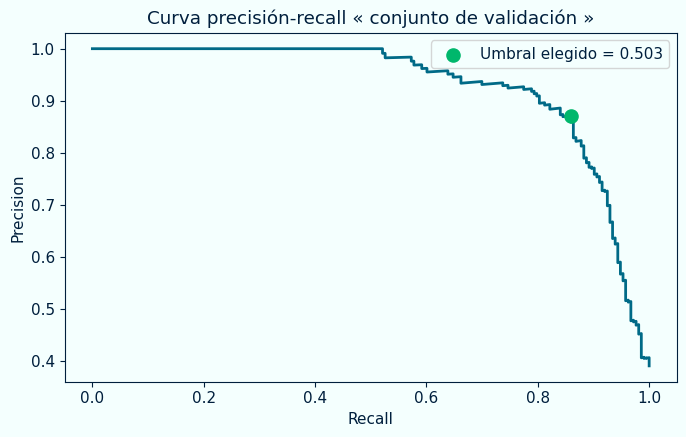

In [ ]:
from sklearn.metrics import precision_recall_curve, f1_score

y_proba_val = mejor_pipeline.predict_proba(X_val)[:, 1]
precisiones, recalls, umbrales = precision_recall_curve(y_val, y_proba_val)

f1_scores = 2 * (precisiones[:-1] * recalls[:-1]) / (precisiones[:-1] + recalls[:-1] + 1e-9)
idx_mejor_f1 = np.argmax(f1_scores)
UMBRAL_ELEGIDO = umbrales[idx_mejor_f1]

print(f"Umbral por defecto: 0.500")
print(f"Umbral elegido por F1 en validación: {UMBRAL_ELEGIDO:.3f}")
print(f"F1 en validación con umbral 0.5:            {f1_score(y_val, (y_proba_val >= 0.5).astype(int)):.4f}")
print(f"F1 en validación con umbral {UMBRAL_ELEGIDO:.3f}:        {f1_scores[idx_mejor_f1]:.4f}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(recalls, precisiones, color=FF_TEAL, linewidth=2)
ax.scatter([recalls[idx_mejor_f1]], [precisiones[idx_mejor_f1]], color=FF_VERDE, s=90, zorder=5,
           label=f"Umbral elegido = {UMBRAL_ELEGIDO:.3f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Curva precisión-recall « conjunto de validación »")
ax.legend()
plt.tight_layout()
plt.show()


**Alternativa descartada:** ¿Umbral fijo de 0.5 o un umbral ajustado con la curva precisión-recall? Pruébala tú y mira qué habría pasado en el [Explorador de decisiones](https://fuzzyfrog.ai/es/ai-lab/proyectos/educacion/modelado-retencion-estudiantil/#explorador-umbral_alerta).

### Evaluación final en test

El conjunto de test no se ha tocado hasta esta celda: ni en la validación cruzada, ni en la afinación de hiperparámetros, ni en la elección del umbral. Esta es la única vez que se usa, y se usa una sola vez.

In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

y_proba_test = mejor_pipeline.predict_proba(X_test)[:, 1]
y_pred_test_05      = (y_proba_test >= 0.5).astype(int)
y_pred_test_ajustado = (y_proba_test >= UMBRAL_ELEGIDO).astype(int)

print("── Umbral 0.5 ──")
print(classification_report(y_test, y_pred_test_05, target_names=["Graduate", "Dropout"]))
print(f"AUC: {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(f"── Umbral ajustado ({UMBRAL_ELEGIDO:.3f}) ──")
print(classification_report(y_test, y_pred_test_ajustado, target_names=["Graduate", "Dropout"]))

fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test_ajustado, display_labels=["Graduate", "Dropout"], ax=ax, colorbar=False,
    cmap="Greens"
)
ax.set_title(f"Umbral {UMBRAL_ELEGIDO:.3f}")
plt.tight_layout()
plt.show()


── Umbral 0.5 ──
              precision    recall  f1-score   support

    Graduate       0.89      0.92      0.90       332
     Dropout       0.86      0.83      0.85       213

    accuracy                           0.88       545
   macro avg       0.88      0.87      0.88       545
weighted avg       0.88      0.88      0.88       545

AUC: 0.9452

── Umbral ajustado (0.503) ──
              precision    recall  f1-score   support

    Graduate       0.89      0.92      0.90       332
     Dropout       0.86      0.83      0.85       213

    accuracy                           0.88       545
   macro avg       0.88      0.87      0.88       545
weighted avg       0.88      0.88      0.88       545



### Tabla comparativa de modelos

Resumen del benchmarking de la sección 4, más el modelo final afinado, evaluado en test.

In [ ]:
df_modelos_final = df_modelos.copy()
df_modelos_final.loc[f"{mejor_modelo_nombre} (afinado, umbral ajustado)"] = {
    "AUC":    roc_auc_score(y_test, y_proba_test),
    "Recall": recall_score(y_test, y_pred_test_ajustado),
    "F1":     f1_score(y_test, y_pred_test_ajustado),
}
df_modelos_final.sort_values("AUC", ascending=False)


,AUC,Recall,F1
"Random Forest (afinado, umbral ajustado)",0.945161,0.830986,0.846890
Random Forest,0.931211,0.796985,0.835961
Logistic Regression,0.930559,0.843216,0.842607
Gradient Boosting,0.930477,0.804020,0.839318
XGBoost,0.926943,0.790955,0.828324
SVM,0.922416,0.780905,0.817319


## 6. Interpretabilidad con SHAP

No basta con decir que el modelo funciona. SHAP explica qué variables empujan cada predicción hacia deserción o hacia graduación, a nivel global y a nivel de un estudiante individual. Con el corte temprano ya aplicado, estas son variables que existen antes de que el problema sea evidente, no una descripción del desenlace.

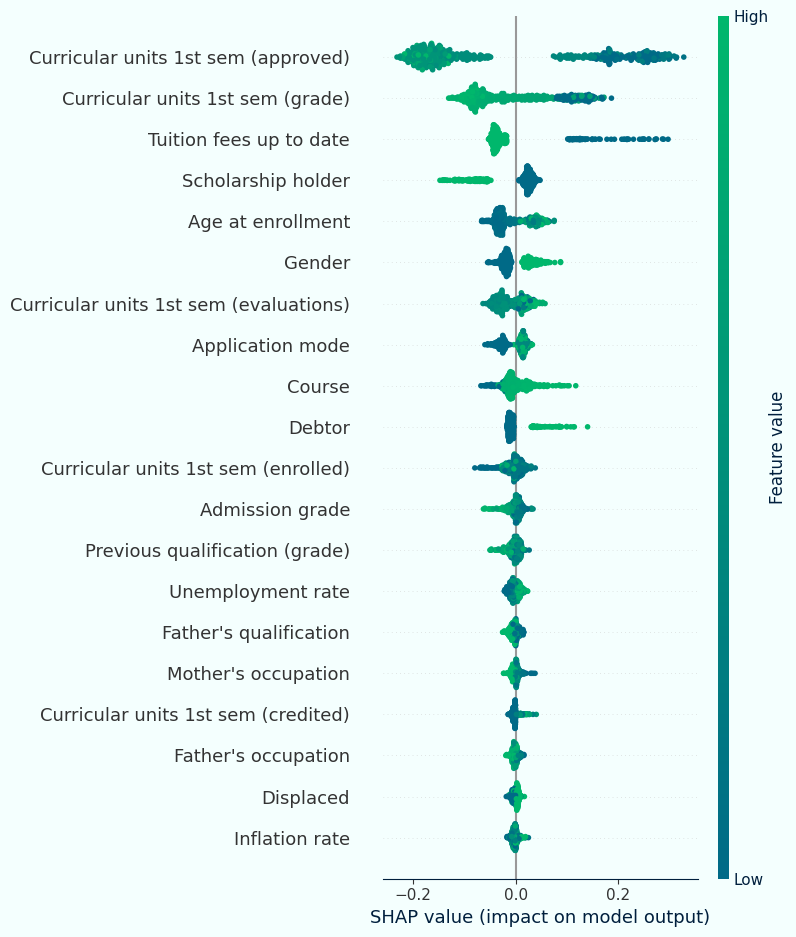

In [ ]:
import shap
from matplotlib.colors import LinearSegmentedColormap

# summary_plot no lee plt.rcParams: trae su propio colormap cableado
# (el rojo-azul por default de SHAP). Se le pasa uno propio, de la paleta
# de marca, para que respete el mismo criterio que el resto de las gráficas.
FF_CMAP = LinearSegmentedColormap.from_list("ff_shap", [FF_TEAL, FF_VERDE])

modelo_final     = mejor_pipeline.named_steps["modelo"]
escalador_final  = mejor_pipeline.named_steps["escalado"]
X_train_escalado = escalador_final.transform(X_train)
X_test_escalado  = escalador_final.transform(X_test)

# El explainer depende del tipo de modelo que haya ganado el benchmarking:
# TreeExplainer para modelos de árboles (rápido, exacto, sin fuga de datos
# porque usa feature_perturbation="tree_path_dependent" en vez de un fondo
# de referencia), LinearExplainer si ganó Logistic Regression, y un
# explainer general sobre una muestra si ganó SVM.
modelos_arbol = (RandomForestClassifier, GradientBoostingClassifier, XGBClassifier)

if isinstance(modelo_final, modelos_arbol):
    explicador = shap.TreeExplainer(modelo_final, feature_perturbation="tree_path_dependent")
    X_shap     = X_test_escalado
elif isinstance(modelo_final, LogisticRegression):
    explicador = shap.LinearExplainer(modelo_final, X_train_escalado)
    X_shap     = X_test_escalado
else:
    fondo      = shap.sample(X_train_escalado, 100, random_state=SEED)
    explicador = shap.Explainer(lambda arr: modelo_final.predict_proba(arr)[:, 1], fondo)
    X_shap     = X_test_escalado[:200]

shap_values = explicador(X_shap)

# Con algunos modelos (por ejemplo GradientBoostingClassifier de scikit-learn),
# TreeExplainer devuelve un eje extra por clase aunque el problema sea binario:
# shape (n_filas, n_variables, 2) en vez de (n_filas, n_variables). Nos quedamos
# solo con la clase positiva (Dropout) para tener una sola explicación por fila.
if shap_values.values.ndim == 3:
    shap_values = shap_values[..., 1]

shap.summary_plot(shap_values, X_shap, feature_names=X.columns.tolist(), cmap=FF_CMAP, show=True)


In [ ]:
n_shap     = X_shap.shape[0]
proba_shap = mejor_pipeline.predict_proba(X_test.iloc[:n_shap])[:, 1]
idx_ejemplo = int(np.argmax(proba_shap))

print(f"Estudiante de mayor riesgo entre los explicados con SHAP: "
      f"probabilidad de deserción = {proba_shap[idx_ejemplo]:.3f}")
# El waterfall recibe una Explanation con los nombres reales de las variables y sus
# valores originales (sin escalar), para que cada barra diga qué variable es y cuánto vale.
explicacion_individual = shap.Explanation(
    values=shap_values.values[idx_ejemplo],
    base_values=shap_values.base_values[idx_ejemplo],
    data=X_test.iloc[idx_ejemplo].values,
    feature_names=X.columns.tolist(),
)
shap.plots.waterfall(explicacion_individual)


Estudiante de mayor riesgo entre los explicados con SHAP: probabilidad de deserción = 1.000


## 7. Exportación para el Explorador de decisiones

- Los resultados de cada alternativa se guardan en `explorador_resultados.json`, organizados por decisión.
- De aquí salen los números reales de cada opción del Explorador de decisiones del artículo.

In [ ]:
def limpiar(d):
    out = {}
    for k, v in d.items():
        if isinstance(v, (float, np.floating)):
            out[k] = None if not np.isfinite(v) else round(float(v), 4)
        elif isinstance(v, (int, np.integer)):
            out[k] = int(v)
        else:
            out[k] = v
    return out

EXPLORADOR = {
    "meta": {
        "ejecutado": "2026-09-25",
        "dataset": "real, UCI id 697",
        "filas_tras_filtrar": int(df.shape[0]),
        "anclas_pendientes": ["corte_temporal", "manejo_desbalance", "escalado_sin_fuga",
                              "metrica_seleccion", "umbral_alerta"],
    },
    "corte_temporal": {
        "completo":  {"auc": round(float(auc_completo), 4), "recall": round(float(recall_completo), 4)},
        "temprano":  {"auc": round(float(auc_temprano), 4), "recall": round(float(recall_temprano), 4)},
        "elegido": CORTE_ELEGIDO,
        "columnas_descartadas": COLUMNAS_2DO_SEM,
    },
    "manejo_desbalance": {
        "estrategia_elegida": ESTRATEGIA_ELEGIDA,
        "recall_por_estrategia": limpiar(df_desbalance["recall"].to_dict()),
    },
    "escalado_sin_fuga": {
        "auc_con_fuga": round(float(auc_con_fuga), 4),
        "auc_sin_fuga": round(float(auc_sin_fuga), 4),
    },
    "metrica_seleccion": {
        "accuracy_modelo_trampa": round(float(acc_dummy), 4),
        "recall_modelo_trampa": round(float(recall_dummy), 4),
        "mejor_modelo": mejor_modelo_nombre,
        "auc_mejor_modelo": round(float(df_modelos.loc[mejor_modelo_nombre, "AUC"]), 4),
    },
    "umbral_alerta": {
        "umbral_default": 0.5,
        "umbral_elegido": round(float(UMBRAL_ELEGIDO), 4),
        "f1_val_default": round(float(f1_score(y_val, (y_proba_val >= 0.5).astype(int))), 4),
        "f1_val_ajustado": round(float(f1_scores[idx_mejor_f1]), 4),
    },
    "evaluacion_final_test": {
        "auc": round(float(roc_auc_score(y_test, y_proba_test)), 4),
        "recall_umbral_ajustado": round(float(recall_score(y_test, y_pred_test_ajustado)), 4),
        "f1_umbral_ajustado": round(float(f1_score(y_test, y_pred_test_ajustado)), 4),
    },
}

import json as _json
with open("explorador_resultados.json", "w", encoding="utf-8") as f:
    _json.dump(EXPLORADOR, f, indent=2, ensure_ascii=False)

print(_json.dumps(EXPLORADOR, indent=2, ensure_ascii=False))


{
  "meta": {
    "ejecutado": "2026-09-25",
    "dataset": "real, UCI id 697",
    "filas_tras_filtrar": 3630,
    "anclas_pendientes": [
      "corte_temporal",
      "manejo_desbalance",
      "escalado_sin_fuga",
      "metrica_seleccion",
      "umbral_alerta"
    ]
  },
  "corte_temporal": {
    "completo": {
      "auc": 0.9463,
      "recall": 0.8302
    },
    "temprano": {
      "auc": 0.9303,
      "recall": 0.791
    },
    "elegido": "temprano",
    "columnas_descartadas": [
      "Curricular units 2nd sem (credited)",
      "Curricular units 2nd sem (enrolled)",
      "Curricular units 2nd sem (evaluations)",
      "Curricular units 2nd sem (approved)",
      "Curricular units 2nd sem (grade)",
      "Curricular units 2nd sem (without evaluations)"
    ]
  },
  "manejo_desbalance": {
    "estrategia_elegida": "smote",
    "recall_por_estrategia": {
      "sin_balanceo": 0.791,
      "class_weight_balanced": 0.8372,
      "smote": 0.8432
    }
  },
  "escalado_sin_fuga": {

## 8. Checklist metodológico

Verificación explícita, con aserciones que corren de verdad, de que no hay fuga de datos entre entrenamiento y prueba, de que las variables descartadas por la decisión de corte temporal de verdad no entraron al modelo, y de que el modelo predice realmente lo que el notebook dice que predice.

In [ ]:
print("Checklist metodológico\n" + "="*40)

# 1. El corte temporal se respetó: ninguna columna de 2do semestre llegó al modelo final
assert not any("2nd sem" in c for c in X_train.columns), \
    "Hay columnas de 2do semestre en X_train: rompe la promesa de alerta temprana"
assert not any("2nd sem" in c for c in X_test.columns), \
    "Hay columnas de 2do semestre en X_test: rompe la promesa de alerta temprana"
print("1. Ninguna variable de 2do semestre llegó al set de entrenamiento ni de prueba: OK")

# 2. Sin overlap de índices entre las tres particiones
idx_train, idx_val, idx_test = set(X_train.index), set(X_val.index), set(X_test.index)
assert idx_train.isdisjoint(idx_val),  "Hay filas repetidas entre train y val"
assert idx_train.isdisjoint(idx_test), "Hay filas repetidas entre train y test"
assert idx_val.isdisjoint(idx_test),   "Hay filas repetidas entre val y test"
print("2. Sin overlap de índices entre train / val / test: OK")

# 3. El escalador del pipeline final se ajustó solo con X_train
media_manual = X_train.mean().values
media_pipeline = mejor_pipeline.named_steps["escalado"].mean_
assert np.allclose(media_manual, media_pipeline, atol=1e-6), \
    "La media del escalador no corresponde a X_train: hay fuga de datos"
print("3. El StandardScaler del pipeline final se ajustó solo con X_train: OK")

# 4. El umbral se eligió con validación, nunca con test: se recalcula desde cero solo
#    con y_val y debe coincidir con el umbral que usó la evaluación final
prec_v, rec_v, umb_v = precision_recall_curve(y_val, mejor_pipeline.predict_proba(X_val)[:, 1])
f1_v = 2 * (prec_v[:-1] * rec_v[:-1]) / (prec_v[:-1] + rec_v[:-1] + 1e-9)
assert np.isclose(umb_v[np.argmax(f1_v)], UMBRAL_ELEGIDO), \
    "El umbral elegido no sale de la curva precisión-recall de validación"
print("4. El umbral se ajustó con la curva precisión-recall de validación, no de test: OK")

# 5. El target que predice el modelo es el correcto
pred_manual_primeras5 = mejor_pipeline.predict(X_test.iloc[:5])
assert list(pred_manual_primeras5) == list(y_pred_test_05[:5]), \
    "Las predicciones no corresponden al y_pred usado en la evaluación: revisar indexado"
print("5. El target predicho corresponde a la columna 'desercion', sin desalineación de índices: OK")

# 6. SMOTE, si se usó, no tocó val ni test
if usar_smote:
    assert "smote" in mejor_pipeline.named_steps, "SMOTE no está en el pipeline final"
    print("6. SMOTE vive dentro del Pipeline: se aplicó solo a folds/particiones de entrenamiento, nunca a val ni test: OK")
else:
    print("6. Esta corrida no usó SMOTE (se eligió otra estrategia de desbalance en la Decisión 2): N/A")

print("\nTodas las verificaciones pasaron.")


Checklist metodológico
1. Ninguna variable de 2do semestre llegó al set de entrenamiento ni de prueba: OK
2. Sin overlap de índices entre train / val / test: OK
3. El StandardScaler del pipeline final se ajustó solo con X_train: OK
4. El umbral se ajustó con la curva precisión-recall de validación, no de test: OK
5. El target predicho corresponde a la columna 'desercion', sin desalineación de índices: OK
6. SMOTE vive dentro del Pipeline: se aplicó solo a folds/particiones de entrenamiento, nunca a val ni test: OK

Todas las verificaciones pasaron.


### Resumen automático de resultados

Lectura en texto plano de los mismos números que ya quedaron en `explorador_resultados.json`, para revisar de un vistazo sin tener que abrir el archivo.

In [ ]:
print(f"Corte temporal elegido:        {CORTE_ELEGIDO} "
      f"(AUC completo={auc_completo:.3f} vs temprano={auc_temprano:.3f})")
print(f"Manejo del desbalance elegido: {ESTRATEGIA_ELEGIDA}")
print(f"Mejor modelo del benchmarking: {mejor_modelo_nombre} (AUC CV={df_modelos.loc[mejor_modelo_nombre, 'AUC']:.3f})")
print(f"Umbral de alerta elegido:      {UMBRAL_ELEGIDO:.3f} (default 0.5)")
print(f"Evaluación final en test:      AUC={roc_auc_score(y_test, y_proba_test):.3f} | "
      f"Recall={recall_score(y_test, y_pred_test_ajustado):.3f} | "
      f"F1={f1_score(y_test, y_pred_test_ajustado):.3f}")


Corte temporal elegido:        temprano (AUC completo=0.946 vs temprano=0.930)
Manejo del desbalance elegido: smote
Mejor modelo del benchmarking: Random Forest (AUC CV=0.931)
Umbral de alerta elegido:      0.503 (default 0.5)
Evaluación final en test:      AUC=0.945 | Recall=0.831 | F1=0.847


## Hallazgos principales

- Con todas las variables disponibles, incluidas las del 2do semestre, el modelo alcanza un AUC más alto, pero en buena parte porque esas variables casi describen el desenlace ya ocurrido, no porque lo anticipen. La comparación con el corte temprano deja ese costo medido, no solo señalado.
- El modelo trampa que siempre predice "no deserta" alcanza un Accuracy alto y un Recall de cero: confirma por qué este proyecto elige el modelo con la mejor métrica robusta al desbalance, no con la más fácil de calcular.
- Escalar fuera del pipeline de validación cruzada es un riesgo real de fuga de datos, documentado con una comparación directa, no solo señalado en texto.
- El umbral de alerta se ajusta con la curva precisión-recall de validación, nunca con test, para que la elección del punto de corte no contamine la evaluación final.
- SHAP permite explicar cada predicción individual con variables que existen antes de que el problema sea evidente, lo que convierte al modelo en un insumo de alerta temprana genuina, no en una clasificación de caja negra que describe algo que ya pasó.

<br>

## Siguientes pasos: de caso de estudio a proyecto publicable o listo para producción

Este notebook demuestra el criterio correcto: evaluar sin fugas, contra un modelo trampa, y con las variables que de verdad se conocen a tiempo. Sus resultados describen esta institución y esta cohorte, pero todavía no alcanzan para generalizarlos. Para llevarlo a una revista académica o a un sistema que apoye decisiones institucionales reales, estos son los frentes a fortalecer.

**1. Universo**
- El dataset es de una sola institución portuguesa. Validar el mismo pipeline con datos de otra institución, u otro país, antes de asumir que las mismas variables pesan igual en otro contexto.
- Incorporar variables de proceso educativo en tiempo real (asistencia, participación en plataforma, interacciones con tutores) que existen antes que las calificaciones finales de cualquier semestre.

**2. Periodo**
- Es una sola cohorte. Validar con cohortes de distintos años detecta si el modelo se degrada con el tiempo (drift), algo que un solo corte no puede mostrar.
- Probar cortes temporales intermedios, no solo "admisión + 1er semestre" contra "todo", para encontrar el punto exacto donde el Recall empieza a caer de forma importante.

**3. Robustez**
- Calibrar las probabilidades del modelo (Platt Scaling o Isotonic Regression) antes de usarlas para fijar niveles de riesgo operativos.
- Repetir el benchmarking con bootstrap sobre el conjunto de test, para reportar un intervalo de confianza del AUC y del Recall, no solo el punto estimado.

**4. Validación externa**
- Antes de usarlo para decisiones institucionales reales, correr el modelo contra datos de una institución distinta a la que lo entrenó.
- Definir un proceso de monitoreo una vez desplegado: si el Recall en producción empieza a caer respecto al de este notebook, es la señal de que el modelo necesita reentrenarse.



---


<br>

Made with 💚 by FuzzyFrog.AI